In [ ]:
#@title Install & Imports (Colab safe)
import sys, os, pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import itertools
import ipywidgets as widgets
from IPython.display import display, Markdown, Javascript
import time, csv, io
from google.colab import files

print('Ready! scikit-learn imported.')

Ready! scikit-learn imported.


In [ ]:
#@title Run this once at the start.
# In-notebook "store" for responses (lives for the session)
try:
    _REFLECTIONS
except NameError:
    _REFLECTIONS = {}

def reflection_box(prompt: str, placeholder: str = "Type your thoughts here..."):
    """
    Render a reflection box tied to the actual prompt (question).
    Stores answers in _REFLECTIONS with prompt text as the key.
    """
    title = widgets.HTML(value=f"<b>Reflection:</b> {prompt}")
    ta = widgets.Textarea(
        value=_REFLECTIONS.get(prompt, ""),
        placeholder=placeholder,
        layout={'width': '100%', 'height': '100px'}
    )
    save_btn = widgets.Button(description="Save note")
    status = widgets.Output()

    def on_save(_):
        _REFLECTIONS[prompt] = ta.value
        with status:
            status.clear_output()
            display(Markdown("**Saved for this session.** Scroll to the end to download your reflections."))

    save_btn.on_click(on_save)
    display(widgets.VBox([title, ta, save_btn, status]))

def export_reflections(path: str = "reflections.csv"):
    """
    Export reflections as a CSV with two columns:
    question, response
    """
    with open(path, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["question", "response"])
        for q, ans in _REFLECTIONS.items():
            writer.writerow([q, ans])
    return path

def make_quiz_mc(question, options, correct_index):
    # Render a multiple-choice quiz with instant feedback.
    title = widgets.HTML(value=f"<b>Q:</b> {question}")
    rb = widgets.RadioButtons(options=options, description='')
    btn = widgets.Button(description='Check answer')
    out = widgets.Output()

    def check(_):
        with out:
            out.clear_output()
            i = options.index(rb.value)
            if i == correct_index:
                display(Markdown("**✅ Correct!**"))
            else:
                display(Markdown(f"**❌ Not quite.** The right answer is **{options[correct_index]}**."))
    btn.on_click(check)
    box = widgets.VBox([title, rb, btn, out])
    display(box)

def make_quiz_tf(statement, correct=True):
    # Render a True/False quiz.
    title = widgets.HTML(value=f"<b>True/False:</b> {statement}")
    rb = widgets.RadioButtons(options=['True', 'False'], description='')
    btn = widgets.Button(description='Check answer')
    out = widgets.Output()

    def check(_):
        with out:
            out.clear_output()
            ans = (rb.value == 'True')
            if ans == correct:
                display(Markdown("**✅ Correct!**"))
            else:
                display(Markdown("**❌ Not quite.** Try again."))
    btn.on_click(check)
    box = widgets.VBox([title, rb, btn, out])
    display(box)

def make_reflection(prompt):
    # A short free-response reflection box.
    title = widgets.HTML(value=f"<b>Reflection:</b> {prompt}")
    ta = widgets.Textarea(placeholder='Type your thoughts here...', layout={'width':'100%','height':'80px'})
    btn = widgets.Button(description='Save note (local)')
    out = widgets.Output()
    def save(_):
        with out:
            out.clear_output()
            display(Markdown("Saved for this session. (Copy to your doc if you want to keep it.)"))
    btn.on_click(save)
    display(widgets.VBox([title, ta, btn, out]))

def add_code_toggle():
    # Per-cell Show/Hide code toggle (Jupyter Notebook classic). In other editors, it may be ignored.
    try:
        display(Javascript('''
        if (typeof Jupyter !== "undefined") {
          var cell = Jupyter.notebook.get_selected_cell();
          var idx = Jupyter.notebook.find_cell_index(cell);
          var code_cell = Jupyter.notebook.get_cell(idx);
          if (code_cell.cell_type !== 'code') { }
          else {
            var button = $('<button>Hide/Show code</button>').css({'margin-bottom': '6px'});
            button.on('click', function() {
              $(code_cell.element).find('.input').toggle();
            });
            $(code_cell.element).find('.input').before(button);
          }
        }
        '''))
    except Exception as e:
        display(Markdown("> Toggle not supported in this editor."))

def render_table():
    with table_out:
        table_out.clear_output()
        if user_data:
            df = pd.DataFrame(user_data, columns=["text", "label"])
            display(Markdown(f"**Current entries:** {len(df)}"))
            display(df.tail(10))  # show last few rows so the output stays compact
        else:
            display(Markdown("_No entries yet. Add some above._"))

def add_row(_):
    text = (word_input.value or "").strip()
    label = label_dropdown.value
    if not text:
        with status:
            status.clear_output()
            display(Markdown("⚠️ Please type a word/phrase before adding."))
        return
    user_data.append((text, label))
    word_input.value = ""
    with status:
        status.clear_output()
        display(Markdown(f"✅ Added **{text} → {label}**"))
    render_table()

def save_csv(_):
    if not user_data:
        with status:
            status.clear_output()
            display(Markdown("⚠️ No data to save yet. Add some rows first."))
        return
    df = pd.DataFrame(user_data, columns=["text", "label"])
    df.to_csv("formal_slang.csv", index=False)
    with status:
        status.clear_output()
        display(Markdown(f"📂 Saved **{len(df)} rows** to `formal_slang.csv`."))
    render_table()

def clear_csv(_):
    # Clear the in-memory list
    user_data.clear()
    # Remove file if it exists
    removed = False
    if os.path.exists("formal_slang.csv"):
        try:
            os.remove("formal_slang.csv")
            removed = True
        except Exception as e:
            with status:
                status.clear_output()
                display(Markdown("⚠️ Could not delete `formal_slang.csv`."))
                display(Markdown(str(e)))
    with status:
        status.clear_output()
        if removed:
            display(Markdown("🗑️ Cleared entries and deleted `formal_slang.csv`."))
        else:
            display(Markdown("🧹 Cleared entries. (No `formal_slang.csv` to delete.)"))
    render_table()


def _load_df_flex():
    """
    Return a DataFrame from one of:
      1) existing df (already defined),
      2) user_data list of (text, label),
      3) 'formal_slang.csv' on disk.
    Raises a clear error if none are found.
    """
    # 1) Already loaded df
    if 'df' in globals() and isinstance(df, pd.DataFrame):
        return df.copy()

    # 2) Interactive entries from the widget flow
    if 'user_data' in globals() and isinstance(user_data, list) and len(user_data) > 0:
        return pd.DataFrame(user_data, columns=["text", "label"])

    # 3) Saved CSV
    if os.path.exists("formal_slang.csv"):
        return pd.read_csv("formal_slang.csv")

    raise RuntimeError(
        "No data found. Either add rows with the input widget, define `df`, "
        "or save a file named 'formal_slang.csv'."
    )

def clean_formal_slang_df(raw: pd.DataFrame) -> pd.DataFrame:
    """
    Clean and validate a formal/slang dataset:
      - Ensure columns: text,label
      - Drop NA/empty
      - Strip whitespace
      - Lowercase labels
      - Keep only labels in {'formal','slang'}
      - Drop duplicate rows
    """
    # Ensure required columns exist (allow case-insensitive match)
    cols_lower = {c.lower(): c for c in raw.columns}
    if not {"text", "label"}.issubset(cols_lower.keys()):
        raise AssertionError("CSV must have columns: text,label")

    df2 = raw.rename(columns={cols_lower["text"]: "text", cols_lower["label"]: "label"}).copy()

    # Drop NA/empty
    df2["text"] = df2["text"].astype(str)
    df2["label"] = df2["label"].astype(str)
    df2 = df2.dropna(subset=["text", "label"])
    df2["text"] = df2["text"].str.strip()
    df2["label"] = df2["label"].str.strip().str.lower()

    # Keep only valid labels
    valid_labels = {"formal", "slang"}
    before = len(df2)
    df2 = df2[df2["label"].isin(valid_labels)]
    removed_invalid = before - len(df2)

    # Remove empty text rows
    before2 = len(df2)
    df2 = df2[df2["text"] != ""]
    removed_empty = before2 - len(df2)

    # Drop duplicates
    before3 = len(df2)
    df2 = df2.drop_duplicates(subset=["text", "label"]).reset_index(drop=True)
    dropped_dupes = before3 - len(df2)

    print("Cleaning summary:")
    print(f"- Removed rows with invalid labels: {removed_invalid}")
    print(f"- Removed rows with empty text: {removed_empty}")
    print(f"- Dropped duplicate rows: {dropped_dupes}")

    # Class distribution
    print("\nClass distribution:")
    print(df2["label"].value_counts())

    return df2

def on_download_clicked(b):
    try:
        path = export_reflections("my_reflections.csv")  # uses updated {question: response}
        files.download(path)
        with status:
            status.clear_output()
            display(Markdown("✅ Your reflections file is downloading..."))
    except Exception as e:
        with status:
            status.clear_output()
            display(Markdown("⚠️ Make sure you've filled in and saved at least one reflection."))
            display(Markdown(str(e)))

print("Helpers Ready!")

Helpers Ready!


In [ ]:
#@title Mini-Quiz
# Requires: run the "Classroom helpers (run once)" cell at the top.
try:
    make_quiz_mc(
        "Which best describes machine learning?",
        ["Writing explicit rules for every case", "Learning patterns from data", "A new programming language"],
        1
    )
    make_quiz_mc(
        "Which of these do you think is an example of machine learning in real life?",
        ["Autocorrect on your phone", "Spam filters in email", "Your TikTok's for you page", "All of the above"],
        3
    )
    # make_quiz_mc(
    #     "Which task is typically classification?",
    #     ["Predict tomorrow's temperature (a number)", "Decide if an email is spam or not", "Estimate house prices"],
    #     1
    # )
except NameError:
    print("⚠️ Please run the 'Classroom helpers (run once)' cell at the top, then re-run this cell.")


# Formal vs. Slang — DIY Text Classifier (Colab Starter)

Train a very simple classifier to detect whether a word/short phrase is **formal** or **slang** using your **own dataset**.

**Dataset format (`formal_slang.csv`)**

```
text,label
therefore,formal
omg,slang
```

In [ ]:
#@title Reflection: In one or two sentences, what do you think this notebook will help you learn?
reflection_box("In one or two sentences, what do you think this notebook will help you learn?")

## 1) Upload your data

Upload a CSV named **`formal_slang.csv`** with two columns: `text,label`. Use the template to get started.

In [ ]:
#@title Enter You Data Here
try:
    user_data
except NameError:
    user_data = []

# Widgets
word_input = widgets.Text(placeholder='Type a word or phrase...', description='Text:')
label_dropdown = widgets.Dropdown(options=['formal', 'slang'], description='Label:')
add_btn = widgets.Button(description="Add", button_style='success')
save_btn = widgets.Button(description="Save to CSV", button_style='info')
clear_btn = widgets.Button(description="Clear CSV", button_style='danger')
status = widgets.Output()
table_out = widgets.Output()

# Wire up
add_btn.on_click(add_row)
save_btn.on_click(save_csv)
clear_btn.on_click(clear_csv)

# UI
display(
    word_input,
    label_dropdown,
    widgets.HBox([add_btn, save_btn, clear_btn]),
    status,
    table_out
)

# Initial table render
render_table()

Text(value='', description='Text:', placeholder='Type a word or phrase...')

Dropdown(description='Label:', options=('formal', 'slang'), value='formal')

Output()

Output()

In [ ]:
#@title 📂 Load or Upload Your Dataset (CSV or In-Notebook Data)

status = widgets.Output()
preview = widgets.Output()

btn_upload = widgets.Button(description="Upload CSV", button_style="primary")
btn_use_local = widgets.Button(description="Use My In-Notebook Data", button_style="info")
btn_template = widgets.Button(description="Download Template CSV", button_style="success")

def _clean_df(raw: pd.DataFrame) -> pd.DataFrame:
    # Accept case-insensitive columns; rename to text,label
    cols_lower = {c.lower(): c for c in raw.columns}
    if not {"text", "label"}.issubset(cols_lower):
        raise AssertionError("CSV must have columns: text,label")
    df2 = raw.rename(columns={cols_lower["text"]: "text", cols_lower["label"]: "label"}).copy()

    # Basic cleanup
    df2["text"] = df2["text"].astype(str).str.strip()
    df2["label"] = df2["label"].astype(str).str.strip().str.lower()

    # Keep only valid labels, drop empties & duplicates
    valid_labels = {"formal", "slang"}
    df2 = df2[df2["label"].isin(valid_labels)]
    df2 = df2[df2["text"] != ""]
    df2 = df2.drop_duplicates(subset=["text", "label"]).reset_index(drop=True)
    return df2

def _show_preview(df: pd.DataFrame, source: str):
    with preview:
        preview.clear_output()
        display(Markdown(f"**Loaded from:** `{source}` — **Rows:** {len(df)}"))
        display(df.head())
        display(Markdown("**Class distribution:**"))
        display(df["label"].value_counts())

def on_upload_clicked(_):
    with status:
        status.clear_output()
        display(Markdown("📤 **Choose a CSV** with columns `text,label`..."))
    uploaded = files.upload()
    if not uploaded:
        with status:
            status.clear_output()
            display(Markdown("⚠️ No file selected."))
        return
    # Read the first uploaded file regardless of its name
    fname = next(iter(uploaded.keys()))
    raw = pd.read_csv(io.BytesIO(uploaded[fname]))
    df_loaded = _clean_df(raw)
    # Save a normalized copy for downstream steps
    df_loaded.to_csv("formal_slang.csv", index=False)
    globals()["df"] = df_loaded  # expose as df for later cells
    with status:
        status.clear_output()
        display(Markdown(f"✅ Loaded and saved as `formal_slang.csv` (from `{fname}`)"))
    _show_preview(df_loaded, f"upload: {fname}")

def on_use_local_clicked(_):
    # Use the in-notebook data built via your interactive entry cell
    if "user_data" not in globals() or not isinstance(user_data, list) or len(user_data) == 0:
        with status:
            status.clear_output()
            display(Markdown("⚠️ No in-notebook entries found. Add rows in the dataset builder first."))
        return
    raw = pd.DataFrame(user_data, columns=["text", "label"])
    df_loaded = _clean_df(raw)
    df_loaded.to_csv("formal_slang.csv", index=False)
    globals()["df"] = df_loaded
    with status:
        status.clear_output()
        display(Markdown("✅ Loaded from in-notebook entries and saved as `formal_slang.csv`"))
    _show_preview(df_loaded, "in-notebook data (user_data)")

def on_template_clicked(_):
    # Provide a tiny starter template, then download it
    template = pd.DataFrame(
        [("therefore", "formal"), ("omg", "slang")],
        columns=["text", "label"]
    )
    template.to_csv("formal_slang_template.csv", index=False)
    files.download("formal_slang_template.csv")
    with status:
        status.clear_output()
        display(Markdown("📄 Downloaded **formal_slang_template.csv** — fill it and upload using the button."))

btn_upload.on_click(on_upload_clicked)
btn_use_local.on_click(on_use_local_clicked)
btn_template.on_click(on_template_clicked)

display(
    widgets.HBox([btn_upload, btn_use_local, btn_template]),
    status,
    preview
)


Output()

Output()

Saving slang_formal.csv to slang_formal.csv


Rows, Columns: (100, 2)


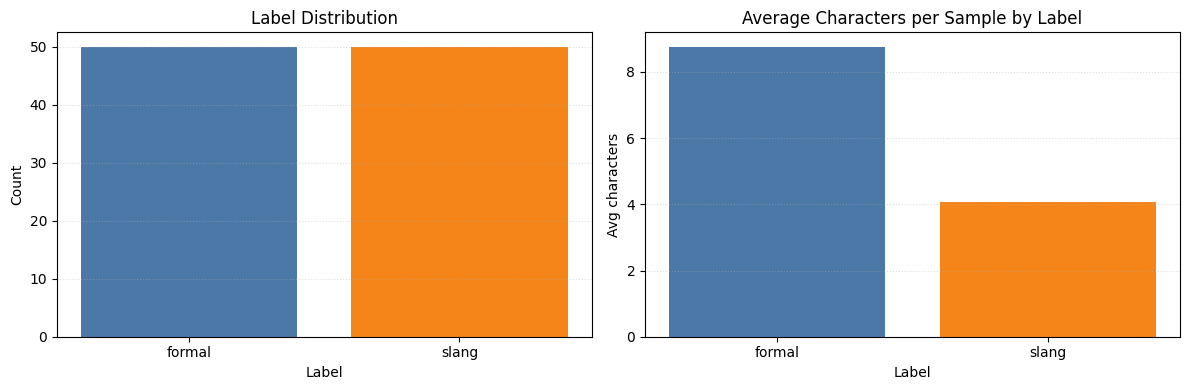

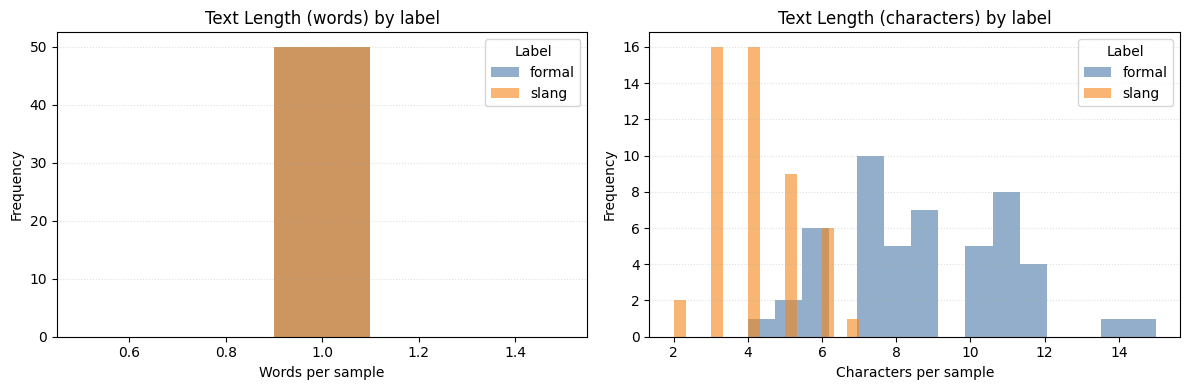

In [ ]:
#@title 📊 This is how your Data look like (colored by label)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def visualize_dataset(df: pd.DataFrame):
    # Clean
    df = df[['text','label']].dropna().copy()
    df['text']  = df['text'].astype(str).str.strip()
    df['label'] = df['label'].astype(str).str.strip().str.lower()

    # Colors for labels (add more as needed)
    label_colors = {
        'formal': '#4c78a8',  # blue
        'slang':  '#f58518',  # orange
    }
    def color_for(lbl, fallback='#888888'):
        return label_colors.get(lbl, fallback)

    # ---- Overview
    print("Rows, Columns:", df.shape)

    # ---- Precompute stats
    label_counts = df['label'].value_counts().sort_values(ascending=False)
    word_len = df['text'].str.split().map(len)
    char_len = df['text'].str.len()
    stats = (
        df.assign(words=word_len, chars=char_len)
          .groupby('label').agg({'words':'mean','chars':'mean'})
          .sort_values('words', ascending=False)
    )

    # ===== Row 1: Label distribution | Avg chars per label =====
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

    # Label distribution with per-bar colors
    axes[0].bar(
        label_counts.index,
        label_counts.values,
        color=[color_for(lbl) for lbl in label_counts.index]
    )
    axes[0].set_title('Label Distribution')
    axes[0].set_xlabel('Label'); axes[0].set_ylabel('Count')
    axes[0].grid(axis='y', linestyle=':', alpha=0.4)

    # Average characters per label with per-bar colors
    axes[1].bar(
        stats.index,
        stats['chars'].values,
        color=[color_for(lbl) for lbl in stats.index]
    )
    axes[1].set_title('Average Characters per Sample by Label')
    axes[1].set_xlabel('Label'); axes[1].set_ylabel('Avg characters')
    axes[1].grid(axis='y', linestyle=':', alpha=0.4)

    plt.tight_layout()
    plt.show()

    # ===== Row 2: Word length hist | Char length hist (overlaid by label) =====
    bins_w = max(5, min(30, int(word_len.max()) if len(word_len) else 5))
    bins_c = max(5, min(30, int(char_len.max()) if len(char_len) else 5))

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

    # Overlaid histograms by label (words)
    for lbl in df['label'].unique():
        data = word_len[df['label'] == lbl]
        if len(data) == 0:
            continue
        axes[0].hist(data, bins=bins_w, alpha=0.6, label=lbl, color=color_for(lbl))
    axes[0].set_title('Text Length (words) by label')
    axes[0].set_xlabel('Words per sample'); axes[0].set_ylabel('Frequency')
    axes[0].grid(axis='y', linestyle=':', alpha=0.4)
    axes[0].legend(title='Label')

    # Overlaid histograms by label (characters)
    for lbl in df['label'].unique():
        data = char_len[df['label'] == lbl]
        if len(data) == 0:
            continue
        axes[1].hist(data, bins=bins_c, alpha=0.6, label=lbl, color=color_for(lbl))
    axes[1].set_title('Text Length (characters) by label')
    axes[1].set_xlabel('Characters per sample'); axes[1].set_ylabel('Frequency')
    axes[1].grid(axis='y', linestyle=':', alpha=0.4)
    axes[1].legend(title='Label')

    plt.tight_layout()
    plt.show()

# call it
visualize_dataset(df)



In [ ]:
#@title Reflection: What does the 'label' column represent in our dataset?
reflection_box("What does the 'label' column represent in our dataset?")


## 2) Clean & sanity checks

In [ ]:

# Load from df / user_data / CSV
_raw = _load_df_flex()
df = clean_formal_slang_df(_raw)

Cleaning summary:
- Removed rows with invalid labels: 0
- Removed rows with empty text: 0
- Dropped duplicate rows: 0

Class distribution:
label
formal    50
slang     50
Name: count, dtype: int64


## 3) Split train/test

In [ ]:
#@title Mini-Quiz
# Requires: run the "Classroom helpers (run once)" cell at the top.
try:
    make_quiz_mc(
        "Which of these words is more formal?",
        ["Therefore", "Rizz", "Skibidi"],
        0
    )
    make_quiz_mc(
        "Which of these is slang?",
        ["However", "Nevertheless", "Sus"],
        2
    )
except NameError:
    print("⚠️ Please run the 'Classroom helpers (run once)' cell at the top, then re-run this cell.")


In [ ]:
#@title Splitting Data into Training and Testing Sets
# Split the data into training and testing sets.
# df['text'].values: all the text data (our input features)
# df['label'].values: all the labels (the answers we want to predict)
# test_size=0.2: keep 20% of the data for testing, 80% for training
# random_state=42: a "seed" to make sure the split is always the same every time
# stratify=df['label']: makes sure the train/test split keeps the same balance of labels
X_train, X_test, y_train, y_test = train_test_split(
    df['text'].values, df['label'].values, test_size=0.2, random_state=42, stratify=df['label'])
len(X_train), len(X_test)

(80, 20)

In [ ]:
#@title Reflection: What’s one thing you changed during training and what happened?
reflection_box("What’s one thing you changed during training and what happened?")


## 4) Train simple baseline models

- **Bag-of-Words + Naive Bayes**
- **Bag-of-Words + Logistic Regression**

We use unigrams+bigrams to catch slangy contractions and acronyms.

In [ ]:
#@title Train baselines

# Create a "bag of words" converter:
# CountVectorizer turns text into numbers (counts of words or word-pairs).
# ngram_range=(1,2) means we look at single words (1) and pairs of words (2).
# min_df=1 means we keep words that appear at least once.
bow = CountVectorizer(ngram_range=(1,2), min_df=1)

# Build a pipeline for the Naive Bayes model:
# - First step: turn text into numbers using 'bow'
# - Second step: train a Multinomial Naive Bayes classifier
nb = Pipeline([
    ('vec', bow),
    ('clf', MultinomialNB())
])

# Build a pipeline for the Logistic Regression model:
# - First step: turn text into numbers using 'bow'
# - Second step: train a Logistic Regression classifier
# max_iter=1000 makes sure it has enough steps to finish training
logreg = Pipeline([
    ('vec', bow),
    ('clf', LogisticRegression(max_iter=1000))
])

# Train (fit) both models on the training data
nb.fit(X_train, y_train)
logreg.fit(X_train, y_train)

print('Done training both models.')


Done training both models.


In [ ]:
#@title Mini-Quiz
# Requires: run the "Classroom helpers (run once)" cell at the top.
try:
    make_quiz_mc(
        "When we “train” a model, what happens?",
        ["The model looks at examples and learns patterns", "The computer gets physically stronger", "The code runs faster"],
        0
    )
    make_quiz_mc(
        "Why do we test the model after training?",
        ["To check if the computer is hot", "To see if it can make good predictions on new data", "To see if the code is colorful"],
        1
    )
except NameError:
    print("⚠️ Please run the 'Classroom helpers (run once)' cell at the top, then re-run this cell.")


## 5) Evaluate + confusion matrix


=== Naive Bayes ===
Accuracy: 0.6086956521739131
              precision    recall  f1-score   support

      formal       0.57      1.00      0.73        12
       slang       1.00      0.18      0.31        11

    accuracy                           0.61        23
   macro avg       0.79      0.59      0.52        23
weighted avg       0.78      0.61      0.53        23



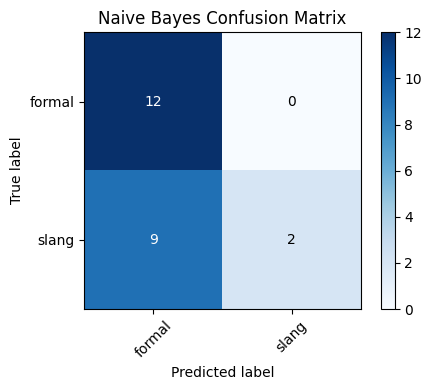


=== LogReg ===
Accuracy: 0.8260869565217391
              precision    recall  f1-score   support

      formal       1.00      0.67      0.80        12
       slang       0.73      1.00      0.85        11

    accuracy                           0.83        23
   macro avg       0.87      0.83      0.82        23
weighted avg       0.87      0.83      0.82        23



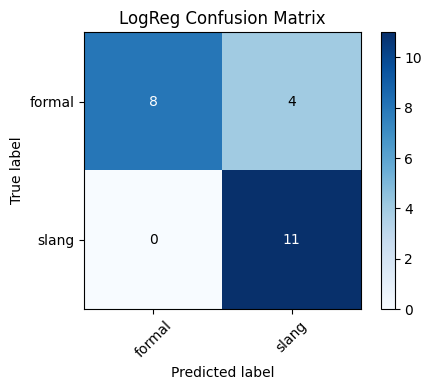


=== Classifier ===
Accuracy: 0.6086956521739131
              precision    recall  f1-score   support

      formal       0.57      1.00      0.73        12
       slang       1.00      0.18      0.31        11

    accuracy                           0.61        23
   macro avg       0.79      0.59      0.52        23
weighted avg       0.78      0.61      0.53        23



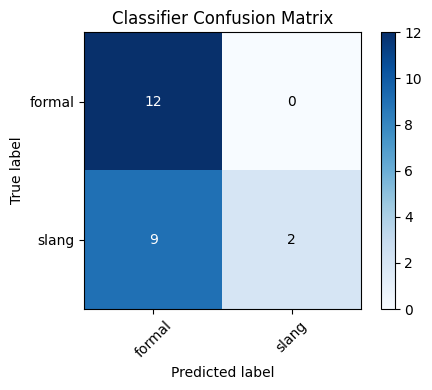

In [ ]:
#@title Checking How Well the Models Work
# Define a function to show a confusion matrix (a table that compares
# the real labels vs. the predicted labels).
def plot_cm(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    # ✅ Fix: convert both to sets before union
    classes = sorted(set(y_true) | set(y_pred))
    plt.figure(figsize=(5,4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha='center', va='center',
                 color="white" if cm[i, j] > cm.max()/2 else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

# Collect available models by name (only those that exist)
available_models = []
if "nb" in globals():
    available_models.append(("Naive Bayes", nb))
if "logreg" in globals():
    available_models.append(("LogReg", logreg))
if "tfidf_logreg" in globals():  # if you used a Pipeline named this
    available_models.append(("TF-IDF + LogReg", tfidf_logreg))
if "model" in globals():  # any generic model var you might have used
    available_models.append(("Model", model))
if "clf" in globals():
    available_models.append(("Classifier", clf))

# Sanity checks for data splits
if "X_test" not in globals() or "y_test" not in globals():
    raise RuntimeError("⚠️ Missing X_test/y_test. Please run your train/test split and training cells first.")

if not available_models:
    raise RuntimeError("⚠️ No trained models found. Train a model (e.g., Naive Bayes or Logistic Regression) before evaluating.")

# Evaluate each available model
for name, clf in available_models:
    preds = clf.predict(X_test)
    print(f"\n=== {name} ===")
    print("Accuracy:", accuracy_score(y_test, preds))
    print(classification_report(y_test, preds))
    plot_cm(y_test, preds, title=f'{name} Confusion Matrix')

In [ ]:
#@title Reflection: Was the output what you expected? Why or why not?
reflection_box("Was the output what you expected? Why or why not?")


## 6) Error analysis: what to add next

In [ ]:
#@title Showing Where the Model Got Answers Wrong
# Define a function to show the errors (where the model predicted wrong).
def show_errors(clf, X, y, n=30):
    # Get predictions from the model
    preds = clf.predict(X)

    # Collect all the mistakes: for each sample, if the prediction
    # is not the same as the true label, save its index, text, true label, and predicted label
    wrong = [(i, X[i], y[i], preds[i]) for i in range(len(X)) if preds[i] != y[i]]

    # Print the total number of mistakes
    print(f'Total mistakes: {len(wrong)}')

    # Show up to 'n' mistakes (default is 30)
    for i, text, true, pred in wrong[:n]:
        print(f'[{i}] "{text}"  true={true}  pred={pred}')


# Check which mistakes Naive Bayes made
print('Naive Bayes errors:')
show_errors(nb, X_test, y_test)

# Check which mistakes Logistic Regression made
print('\nLogReg errors:')
show_errors(logreg, X_test, y_test)


Naive Bayes errors:
Total mistakes: 10
[0] "imo"  true=slang  pred=formal
[1] "goat"  true=slang  pred=formal
[2] "bet"  true=slang  pred=formal
[3] "lmao"  true=slang  pred=formal
[7] "cap"  true=slang  pred=formal
[11] "imho"  true=slang  pred=formal
[15] "seethe"  true=slang  pred=formal
[16] "dope"  true=slang  pred=formal
[18] "tbh"  true=slang  pred=formal
[19] "stan"  true=slang  pred=formal

LogReg errors:
Total mistakes: 10
[0] "imo"  true=slang  pred=formal
[1] "goat"  true=slang  pred=formal
[2] "bet"  true=slang  pred=formal
[3] "lmao"  true=slang  pred=formal
[7] "cap"  true=slang  pred=formal
[11] "imho"  true=slang  pred=formal
[15] "seethe"  true=slang  pred=formal
[16] "dope"  true=slang  pred=formal
[18] "tbh"  true=slang  pred=formal
[19] "stan"  true=slang  pred=formal


## 7) Try your own phrases

In [ ]:
#@title Let's Test the Models on New Words
sample = ['therefore', 'pls', 'regarding', 'gonna', 'idk', 'with regard to']
print('Naive Bayes:', nb.predict(sample))
print('LogReg:', logreg.predict(sample))

Naive Bayes: ['slang' 'slang' 'slang' 'slang' 'slang' 'slang']
LogReg: ['slang' 'slang' 'slang' 'slang' 'slang' 'slang']


## 8) Optional: TF-IDF + Logistic Regression

In [ ]:
#@title Training a Word-Power Model to Predict Better
# Build a pipeline that uses TF-IDF with Logistic Regression
tfidf_logreg = Pipeline([
    # Step 1: Turn text into numbers using TF-IDF
    # - TF-IDF means "Term Frequency - Inverse Document Frequency"
    # - It gives higher weight to words that are important in a text,
    #   and lowers the weight of very common words (like "the", "is").
    ('vec', TfidfVectorizer(ngram_range=(1,2), min_df=1)),

    # Step 2: Train a Logistic Regression classifier
    # - max_iter=1000 just makes sure the training runs long enough to finish
    ('clf', LogisticRegression(max_iter=1000))
])

# Train the pipeline on the training data
tfidf_logreg.fit(X_train, y_train)

# Make predictions on the test set
preds = tfidf_logreg.predict(X_test)

# Print accuracy score (how many correct overall)
print('TF-IDF + LogReg accuracy:', accuracy_score(y_test, preds))

# Print detailed classification report:
# precision, recall, f1-score for each label
print(classification_report(y_test, preds))


TF-IDF + LogReg accuracy: 0.5
              precision    recall  f1-score   support

      formal       0.50      1.00      0.67        10
       slang       0.00      0.00      0.00        10

    accuracy                           0.50        20
   macro avg       0.25      0.50      0.33        20
weighted avg       0.25      0.50      0.33        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 9) Save the best model
Pick whichever performed best and export it.

In [ ]:
#@title Saving the Trained Model to a File
import joblib

# Try to detect a trained model automatically
candidate_models = []
for name in ["tfidf_logreg", "logreg", "nb", "model", "clf"]:
    if name in globals():
        candidate_models.append((name, globals()[name]))

if not candidate_models:
    raise RuntimeError(
        "⚠️ No trained model found. "
        "Please run the training cell first (look for a variable like logreg, nb, or model)."
    )

# Pick the last one trained (last in globals)
best_name, best_model = candidate_models[-1]

joblib.dump(best_model, "formal_slang_classifier.joblib")
print(f"✅ Saved {best_name} as 'formal_slang_classifier.joblib'")

✅ Saved clf as 'formal_slang_classifier.joblib'


## Notes
- Keep *formal* vs. *slang* definitions clear for consistent labels.
- Add edge cases: contractions (e.g., "don't"), acronyms ("idk"), emojis, repeated letters ("soooo"), numbers ("gr8").
- Re-train after each labeling round, focusing on mistakes first.

In [ ]:
#@title 📥 Download Your Reflections Here
# Click the button below to download your saved reflections (CSV with question + response).

download_btn = widgets.Button(description="Download", button_style="success")
status = widgets.Output()
download_btn.on_click(on_download_clicked)
display(download_btn, status)



Button(button_style='success', description='Download', style=ButtonStyle())

Output()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>